# CSE 532 Final Project
-**Jackson Kyle** and **Samuel Cooper**

In this project, we are exploring the TMDB 5000 Movie Dataset and gathering insights on multiple research questions in order to draw conclusions and discover trends in the data. For our research, we are merging the TMDB 5000 Movie Dataset with a Rotten Tomatoes dataset in order to have additional types of factors to consider in our experiments. From the Rotten Tomatoes, we are using the reviews from the movie critic Roger Ebert in order to gather data on the critical success on movies within our original data.



# Research Question 1:
Can we determine what factors correlate, or have the most influence on the success of a movie? For the purposes of this research question, we are defining success as both financial success and critical success. Financial success will be measured by total revenue, profit, and return on investment (ROI). On the other hand, critical success will be measured by fan reviews (from TMDB) and professional reviews (Roger Ebert reviews). To determine which factors correlate the most to the overall success of a movie, we will use multiple columns of data to identify whether or not there is any influence on the success for different factors.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import json

## 1.1) Data Loading:

In [3]:
# Loads in the tmdb datasets
tmdb_movies = pd.read_csv("tmdb_5000_movies.csv")
tmdb_credits = pd.read_csv("tmdb_5000_credits.csv")

# Renames the movie_id column to id for consistency and merging
tmdb_credits.rename(columns={"movie_id":"id"}, inplace=True)
tmdb = pd.merge(tmdb_movies, tmdb_credits, on="id")
# Cleans up duplicate columns created from the merge
tmdb.rename(columns={"title_x":"title"}, inplace=True)
tmdb.drop(columns=["title_y"], inplace=True)

# Loads in the rotten tomatoes datasets with the desired information
rt_movies = pd.read_csv("rotten_tomatoes_movies.csv", usecols=["rotten_tomatoes_link", "movie_title"])
rt_reviews = pd.read_csv("rotten_tomatoes_critic_reviews.csv", usecols=["rotten_tomatoes_link", "critic_name", "review_score"])

# Extracts the Ebert reviews from the dataset
ebert_reviews = rt_reviews.loc[rt_reviews['critic_name'] == "Roger Ebert"].reset_index(drop=True)
ebert_reviews = ebert_reviews.merge(rt_movies[['rotten_tomatoes_link', 'movie_title']],on='rotten_tomatoes_link',how='left')

# Creates the full movie info data frame
movie_info = pd.merge(tmdb, ebert_reviews, left_on="title", right_on="movie_title", how="inner")

# For the sake of our research, we want to add profit and ROI columns:
movie_info["profit"] = movie_info["revenue"] - movie_info["budget"]
movie_info["roi"] = np.where(movie_info["budget"] > 0, movie_info["profit"] / movie_info["budget"], np.nan)

# Splits out the genre entries into names for later research
movie_info["genres"] = movie_info["genres"].apply(json.loads)
movie_info["genre_names"] = movie_info["genres"].apply(lambda x: [g["name"] for g in x])

## 1.2) Data Cleaning

In [4]:
# Homepage and tagline columns are dropped because they don't contain needed information and have multiple null values
movie_info = movie_info.drop(columns=["homepage", "tagline"])

# Removes any movies that had a unknown ($0) budget so that there would be accurate ROI calculations
movie_info = movie_info.dropna(subset=["roi"])

'''Converts the original string rating to a number represented as a percentage'''
def enumerate_rating(score):
    try:
        numerator, denominator = score.split("/")
        return float(numerator) / float(denominator)
    except:
        return None

movie_info["review_score"] = movie_info["review_score"].apply(enumerate_rating)
# Removes all submissions that have an invalid review
movie_info = movie_info.dropna(subset=["review_score"])

# Checks to see how many null values are in each row
print(movie_info.isnull().sum())

budget                  0
genres                  0
id                      0
keywords                0
original_language       0
original_title          0
overview                0
popularity              0
production_companies    0
production_countries    0
release_date            0
revenue                 0
runtime                 0
spoken_languages        0
status                  0
title                   0
vote_average            0
vote_count              0
cast                    0
crew                    0
rotten_tomatoes_link    0
critic_name             0
review_score            0
movie_title             0
profit                  0
roi                     0
genre_names             0
dtype: int64


For cleaning our data, there were multiple choices we made so that we could make the most out of the data for our research questions. To begin, we dropped the movies that did not contain a proper review score, as there were very few of them, and would not contribute to the overall data that much. Secondly, we removed any entries that did not contain a properly formatted ROI, as this would cause problems in our experiments. Following this, we dropped the homepage and tagline rows, as they both contained many null values and had little use to the purpose of our research. Finally, we wanted the review score to be represented as a number, rather than a string, so that calculations could be done easier. To do this, we created the function enumerate_rating to parse the review score and convert it to a float value. We then applied this function to each row of the data.

## 1.3) Descriptive Statistics

In [5]:
print("Revenue Statistics:")
print(movie_info["revenue"].describe())
print(f"var      {movie_info["revenue"].var()}\n")

print("Profit Statistics:")
print(movie_info["profit"].describe())
print(f"var      {movie_info["profit"].var()}\n")

print("ROI Statistics:")
print(movie_info["roi"].describe())
print(f"var      {movie_info["roi"].var()}\n")

print("Ebert Rating Statistics:")
print(movie_info["review_score"].describe())
print(f"var      {movie_info["review_score"].var()}\n")

print("TMDB Rating Statistics:")
print(movie_info["vote_average"].describe())
print(f"var      {movie_info["vote_average"].var()}")

Revenue Statistics:
count    2.385000e+03
mean     1.173744e+08
std      1.780491e+08
min      0.000000e+00
25%      1.383513e+07
50%      5.481930e+07
75%      1.457715e+08
max      2.787965e+09
Name: revenue, dtype: float64
var      3.1701474347497636e+16

Profit Statistics:
count    2.385000e+03
mean     7.600476e+07
std      1.535101e+08
min     -1.500000e+08
25%     -3.000000e+06
50%      2.306344e+07
75%      9.726388e+07
max      2.550965e+09
Name: profit, dtype: float64
var      2.3565350645607428e+16

ROI Statistics:
count     2385.000000
mean        10.924277
std        277.597095
min         -1.000000
25%         -0.198400
50%          1.025447
75%          3.091613
max      12889.386667
Name: roi, dtype: float64
var      77060.14736255954

Ebert Rating Statistics:
count    2385.000000
mean        0.701080
std         0.216807
min         0.000000
25%         0.500000
50%         0.750000
75%         0.875000
max         1.000000
Name: review_score, dtype: float64
var      0

For our first research question, we're defining a movie's success as it's ratings and the revenue/profit it accrued.

Revenue, Profit, and ROI Statistics:
Looking at the statistics obtained from the revenue, ROI, and profits of each movie, it is easy to tell that there are many outliers, and the values are spread across a large range. However, this is to be expected as there are many factors that should contribute to the financial success of a film. From the standard deviation, we can see that there is a wide variation in financial success measured by revenue, profit, and ROI.

Ebert and TMDB Rating Statistics :
From the statistics obtained from the Ebert and TMDB ratings, we can see that the two yield fairly similar mean values for critical success. Using these two in tandem will be strong in determining the critical success of different films. Additionally, the mean and medians of the two are similar, indicating that there are not many outliers. The standard deviation for each is also fairly low, showing that there isn't too much variation in critical success.

Next, we want to answer a number of questions related to group statistics about the metadata that correlates to a movie's success. First, do our factors in our definition of success (critical success and financial success) correlate to each other?

-**Do higher-rated movies make more money? (Using TMDB and Ebert ratings)**\
-**Do higher profit, revenue, and ROI movies have higher ratings?**

In [6]:
print("Average Financial success based upon TMDB Rating:")
financial_success_by_tmdb_rating = movie_info.groupby(pd.cut(movie_info["vote_average"], bins=[0, 5, 6.5, 7.5, 10]), observed=False)[["revenue", "profit", "roi"]].mean()
print(financial_success_by_tmdb_rating.head(4), "\n")

print("Average Financial success based upon Ebert Rating:")
financial_success_by_ebert_rating = movie_info.groupby(pd.cut(movie_info["review_score"], bins=[0, .25, .5, .75, 1]), observed=False)[["revenue", "profit", "roi"]].mean()
print(financial_success_by_ebert_rating.head(4), "\n")

print("Average Critical success based upon profit:")
critical_success_by_profit = movie_info.groupby(pd.qcut(movie_info["profit"], q=5), observed=False)[["vote_average", "review_score"]].mean()
print(critical_success_by_profit.head(10), "\n")

print("Average Critical success based upon revenue:")
critical_success_by_revenue = movie_info.groupby(pd.qcut(movie_info["revenue"], q=5), observed=False)[["vote_average", "review_score"]].mean()
print(critical_success_by_revenue.head(5), "\n")

print("Average Critical success based upon ROI:")
critical_success_by_roi = movie_info.groupby(pd.qcut(movie_info["roi"], q=5), observed=False)[["vote_average", "review_score"]].mean()
print(critical_success_by_roi.head(5))

Average Financial success based upon TMDB Rating:
                   revenue        profit        roi
vote_average                                       
(0.0, 5.0]    4.138850e+07  8.740498e+05   0.177627
(5.0, 6.5]    1.046485e+08  5.849002e+07  16.209060
(6.5, 7.5]    1.316411e+08  9.450110e+07   6.035129
(7.5, 10.0]   1.913838e+08  1.612708e+08   7.249950 

Average Financial success based upon Ebert Rating:
                   revenue        profit        roi
review_score                                       
(0.0, 0.25]   9.362180e+07  5.073795e+07   3.776500
(0.25, 0.5]   1.005659e+08  5.553201e+07   2.343207
(0.5, 0.75]   1.206923e+08  7.674685e+07   3.012970
(0.75, 1.0]   1.297324e+08  9.394551e+07  27.908640 

Average Critical success based upon profit:
                              vote_average  review_score
profit                                                  
(-150000000.001, -6663298.0]      5.967086      0.631184
(-6663298.0, 10051432.4]          6.490985      0.735849

As we can see in the group statistics above, the factors in our definition of success seems to correlate. We can see that on average, movies with lower review scores didn't perform as well financially in revenue, profit, or ROI, and movies with high reviews tended to do better. We can see that within these bins there are some outliers, but for the most part, these terms of success seem to be correlated. Similarly, on average those movies with high profit, revenue, and ROI scored higher critically. From this, we can see that our definition of a movie's success is consitent, and that those factors correlate to each other. Now, we want to see what other factors influence a movie's success.

-**Do higher budget movies make more money?**

In [7]:
financial_success_by_budget = movie_info.groupby(pd.qcut(movie_info["budget"], q=5), observed=False)[["revenue", "profit", "roi"]].mean()
print(financial_success_by_budget.head(5))

                                revenue        profit        roi
budget                                                          
(0.999, 10000000.0]        2.876420e+07  2.400881e+07  43.481150
(10000000.0, 21000000.0]   6.020675e+07  4.437381e+07   2.851097
(21000000.0, 38000000.0]   8.060901e+07  5.153136e+07   1.800431
(38000000.0, 66400000.0]   1.196576e+08  6.900996e+07   1.398274
(66400000.0, 380000000.0]  3.013425e+08  1.932707e+08   1.665215


From this, we can see that on average, movies that had higher budgets resulted in higher revenues and profits. However, lower budget films performed much better in ROI, as the profit margin against the original budget is a lot higher. From this, we can see that budget does seem to correlate to financial success, with high budget movies gaining more revenue and profit, but having less of a benefit from ROI.

-**Do higher budget movies have better ratings?**

In [8]:
critical_success_by_budget = movie_info.groupby(pd.qcut(movie_info["budget"], q=5), observed=False)[["vote_average", "review_score"]].mean()
print(critical_success_by_budget.head(5))

                           vote_average  review_score
budget                                               
(0.999, 10000000.0]            6.725919      0.761364
(10000000.0, 21000000.0]       6.435147      0.706066
(21000000.0, 38000000.0]       6.324174      0.685331
(38000000.0, 66400000.0]       6.188412      0.656384
(66400000.0, 380000000.0]      6.282390      0.690776


From this information, we can see that for the most part, each budget range has fairly similar review averages for the TMDB reviews. However, for the Ebert reviews, we can actually see that on average, the lower budget movies scored higher than high budget movies. This leads us to believe that budget does not correlate as much to critical success. Even though a movie may have a high budget and accrue a high revenue and profit, it still may perform poorly critically.

-**Do different genres correspond to more success?**

In [9]:
movie_genres = movie_info.explode("genre_names")
financial_success_by_genre = movie_genres.groupby("genre_names")[["revenue", "profit", "roi"]].mean()
print("Average Financial success by genre:")
print(financial_success_by_genre, "\n")

print("Average Critical success by genre:")
critical_success_by_genre = movie_genres.groupby("genre_names")[["vote_average", "review_score"]].mean()
print(critical_success_by_genre)

Average Financial success by genre:
                      revenue        profit        roi
genre_names                                           
Action           1.768938e+08  1.125978e+08   2.019840
Adventure        2.316112e+08  1.567217e+08   2.659200
Animation        2.827740e+08  2.010300e+08   4.092986
Comedy           9.896164e+07  6.293258e+07   3.603287
Crime            9.142737e+07  5.494205e+07   2.459739
Documentary      1.719610e+07  1.170157e+07  24.742282
Drama            8.062442e+07  4.909940e+07   3.508370
Family           1.980766e+08  1.362062e+08   3.042994
Fantasy          2.378200e+08  1.644772e+08   2.959771
Foreign          7.000000e+00  0.000000e+00   0.000000
History          1.004758e+08  5.501771e+07   2.017394
Horror           7.276727e+07  4.904267e+07  98.262282
Music            7.045968e+07  4.240393e+07   2.635151
Mystery          1.235278e+08  7.999542e+07  83.887926
Romance          9.500826e+07  6.383469e+07   3.170738
Science Fiction  1.708392e+08

From these tests, we can see that genres perform much differently from both each other, and in terms of critical and financial success. For example, we can see that documentaries perform poorly in total revenue and profit, but tend to have an extremely high ROI and great ratings. Similarly, we can see that horror doesn't make that much total money (revenue and profit), but does phenomenally in terms of ROI. On the other hand, we can see that adventure performs well financially, but is on the lower end of the critical performances. This leads us to believe that different genres perform differently in terms of both critcal and financial success.

-**Does the hype or popularity of a movie correspond to more success?**

In [10]:
print("Average Financial success based upon popularity:")
financial_success_by_popularity = movie_info.groupby(pd.qcut(movie_info["popularity"], q=5), observed=False)[["revenue", "profit", "roi"]].mean()
print(financial_success_by_popularity.head(5), "\n")

print("Average Critical success based upon popularity:")
critical_success_by_popularity = movie_info.groupby(pd.qcut(movie_info["popularity"], q=5), observed=False)[["vote_average", "review_score"]].mean()
print(critical_success_by_popularity.head(5))

Average Financial success based upon popularity:
                                    revenue        profit        roi
popularity                                                          
(0.033299999999999996, 8.632]  2.121368e+07  9.796681e+05   0.481484
(8.632, 15.684]                3.668827e+07  7.978345e+06   3.136486
(15.684, 24.465]               8.146559e+07  4.288734e+07   3.924617
(24.465, 40.237]               1.381773e+08  9.052620e+07   4.904775
(40.237, 271.973]              3.093269e+08  2.376522e+08  42.174022 

Average Critical success based upon popularity:
                               vote_average  review_score
popularity                                               
(0.033299999999999996, 8.632]      6.028092      0.649895
(8.632, 15.684]                    6.181342      0.688417
(15.684, 24.465]                   6.326834      0.700891
(24.465, 40.237]                   6.474843      0.692872
(40.237, 271.973]                  6.973375      0.773323


From these tests we can conclude that popularity has a direct affect on the financial and critical success of a movie. Films that were more popularized performed better in all definitions of success accross the board.

# 1.4) Data Visualization

Using the insights from the experiments conducted previously, there are many options for visual representations to help us draw more conclusions on the datasets.

For our bar graph representations, genre analysis works perfectly. Showing the best performing genres visually is a good way to draw conclusions on the top performing genres.

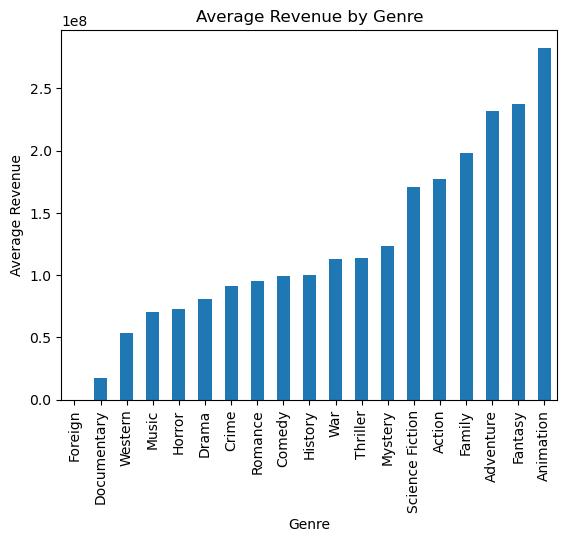

In [11]:
# Gets the genres by average revenue in sorted order
top_genres_by_revenue = financial_success_by_genre.sort_values(by="revenue", ascending=True)
# Plots a bar chart onto the sorted genres
top_genres_by_revenue["revenue"].plot(kind="bar")
plt.title("Average Revenue by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Revenue")
plt.xticks(rotation=90)
plt.show()

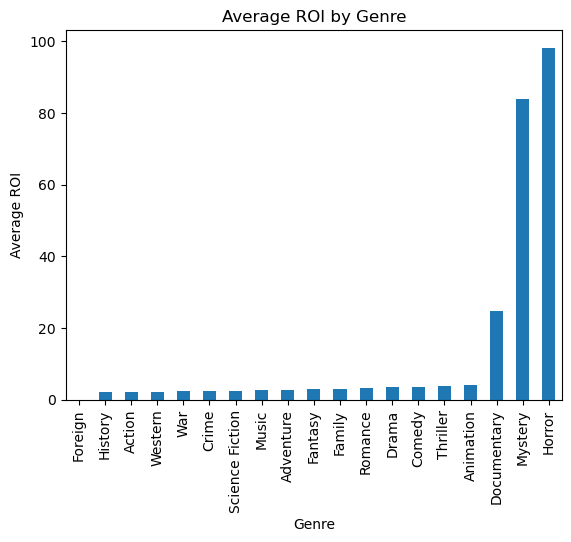

In [12]:
# Gets the genres by average ROI in sorted order
top_genres_by_roi = financial_success_by_genre.sort_values(by="roi", ascending=True)
# Plots a bar chart onto the sorted genres
top_genres_by_roi["roi"].plot(kind="bar")
plt.title("Average ROI by Genre")
plt.xlabel("Genre")
plt.ylabel("Average ROI")
plt.xticks(rotation=90)
plt.show()

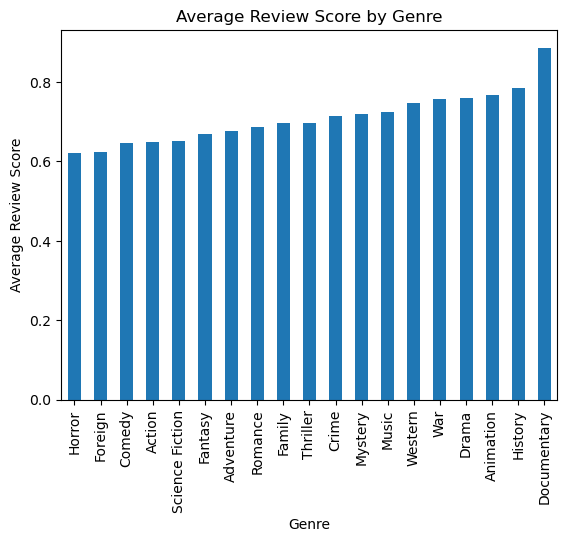

In [13]:
# Gets the genres by average rating in sorted order
top_genres_by_reviews = critical_success_by_genre.sort_values(by="review_score", ascending=True)
# Plots a bar chart onto the sorted genres
top_genres_by_reviews["review_score"].plot(kind="bar")
plt.title("Average Review Score by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Review Score")
plt.xticks(rotation=90)
plt.show()

From our visualizations of the genre statistics, we can conclude that critically, genre does not have too much effect on the overall rating. However, there is a fairly considerable difference financially. We can see that animated movies perform very well financially, being the top earner in average revenue, as well as one of the top performers in terms of ROI. Additionally, we can see that some of the lower revenue movies have the highest ROIs. This shows that these movies perform well despite having a low budget.

For our histogram representation, we decided to display the ROI distribution (Within an understandable range) to show an accurate distribution, rather than the mean which is affected by a number of outliers.

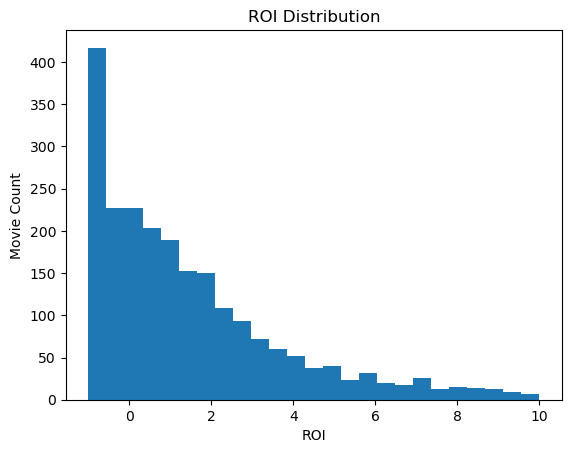

In [14]:
# Plots a histogram on roi within a range that doesn't contain too many outliers
plt.hist(movie_info["roi"], bins=25, range=(-1, 10))
plt.title("ROI Distribution")
plt.xlabel("ROI")
plt.ylabel("Movie Count")
plt.show()

Our histogram shows that the ROI is very right-skewed, with a majority of movies either losing money, breaking even, or making a slight profit. There are fewer movies that make extremely high ROI, which is expected, as a high ROI indicates a fairly low budget in comparison to the profit of the movie. This also shows that our original computed mean is heavily affected by outlier, as a majority of the values are much lower than the original value of 10.9.

For our one of our scatter plot representations, we decided to continue to explore the idea that better rated movies made more money than poorly rated movies. Additionally, we wanted to visualize profit by plotting budget vs revenue to visualize financial performance of different films.

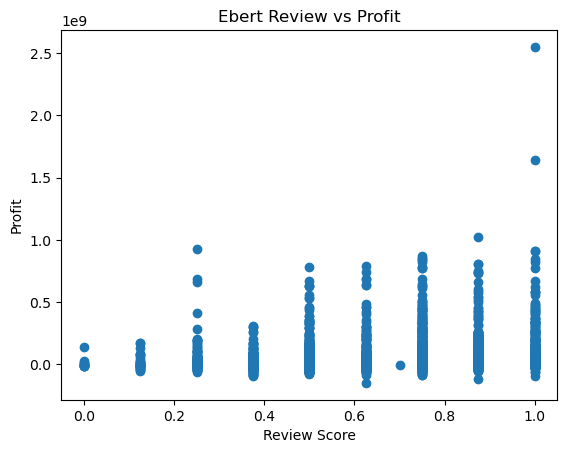

In [15]:
# Creates a scatter plot of Ebert Score vs profit
plt.scatter(movie_info["review_score"], movie_info["profit"])
plt.title("Ebert Review vs Profit")
plt.xlabel("Review Score")
plt.ylabel("Profit")
plt.show()



These results show that higher rated films had a higher tendency of performing well profit-wise. The lower rated films made little to no profit, where the higher rated films had better financial success.

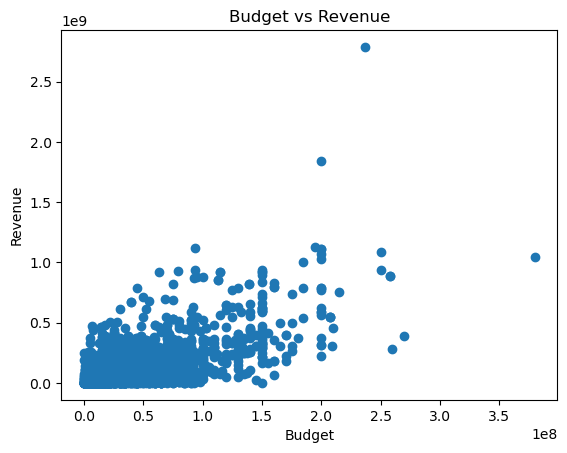

In [16]:
# Plots budget vs revenue to see the relationship between the two
plt.scatter(movie_info["budget"], movie_info["revenue"])
plt.title("Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.show()


The budget vs revenue scatter plot gives us an insight to how budget relates to revenue. As we can see, a lot of movies make a similar revenue to their budget, which checks out in our ROI calculations, where many movies make slightly positive profit.

# Research Question 2:
Using highly the influential factors discovered in in our first research question, can we accurately predict the overall success of different films? 

# 1.5.1 Preprocessing
Data will need to be processed prior to running linear regression or machine learning this segment processes the data. 

In [17]:
import numpy as np
import pandas as pd

from scipy import sparse
import ast
from sklearn import preprocessing
from sklearn.datasets import load_iris, make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import linear_kernel
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    MaxAbsScaler,
    RobustScaler,
    KernelCenterer,
    QuantileTransformer,
    PowerTransformer,
    Normalizer,
    OrdinalEncoder,
    OneHotEncoder,
    KBinsDiscretizer,
    Binarizer,
    normalize,
    MultiLabelBinarizer
)

np.set_printoptions(precision=3, suppress=True)

print(movie_info.head(2).T)
print(movie_info.shape)

                                                                      0  \
budget                                                        237000000   
genres                [{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...   
id                                                                19995   
keywords              [{"id": 1463, "name": "culture clash"}, {"id":...   
original_language                                                    en   
original_title                                                   Avatar   
overview              In the 22nd century, a paraplegic Marine is di...   
popularity                                                   150.437577   
production_companies  [{"name": "Ingenious Film Partners", "id": 289...   
production_countries  [{"iso_3166_1": "US", "name": "United States o...   
release_date                                                 2009-12-10   
revenue                                                      2787965087   
runtime                  

For the linear regression porition of this asssignment three different regression lines willk be studied, one to predict the financial success, one to predict the critical success, and one to predict both. For the regression line the following inputs values will be used budget, original_language, popularity, production countries, release date, vote count, and genre names. 

In [21]:
linear = movie_info.drop(
    columns=[
        'genres',
        'id',
        'keywords',
        'original_title',
        'overview',
        'production_companies',
        'spoken_languages',
        'status',
        'cast',
        'crew',
        'rotten_tomatoes_link',
        'critic_name',
        'movie_title',
        'title',
        'revenue',
    ]
)

linear['release_date'] = pd.to_datetime(linear['release_date'])
linear['year']  = linear['release_date'].dt.year
linear['month'] = linear['release_date'].dt.month
linear['day']   = linear['release_date'].dt.day
linear = linear.drop(columns=['release_date'])


def get_main_country(countries):
    if isinstance(countries, str):
        countries = ast.literal_eval(countries)
    return countries[0]['name'] if countries else None

linear['main_country'] = linear['production_countries'].apply(get_main_country)
linear['is_us_production'] = (linear['main_country'] == 'United States of America').astype(int)
linear = linear.drop(columns=['production_countries', 'main_country'])


linear = pd.get_dummies(linear, columns=['original_language'], prefix='lang')


X = linear.drop(columns=['profit', 'roi', 'vote_average', 'review_score','revenue'])
y = linear[['profit', 'roi', 'vote_average', 'review_score', 'revenue']].copy()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


mlb_genre = MultiLabelBinarizer()

genre_train = pd.DataFrame(
    mlb_genre.fit_transform(X_train['genre_names']),
    columns=mlb_genre.classes_,
    index=X_train.index
)
genre_test = pd.DataFrame(
    mlb_genre.transform(X_test['genre_names']),
    columns=mlb_genre.classes_,
    index=X_test.index
)

X_train = pd.concat([X_train.drop(columns=['genre_names']), genre_train], axis=1)
X_test  = pd.concat([X_test.drop(columns=['genre_names']), genre_test], axis=1)


The data chosen to fit into the model are the budget, popularity, genres, production country, vote count. Production companies, cast, and crew are being left out due to the high number of cardinality for each category. One hot encoding needs a indvidual column for each unique value and using all of these quickly expands the amount of columns to greatly exceed the amount of rows. These kind of features while certainly important to predicting the success of a movie for a specfic audience is important but when considering the scale of the data this quickly becomes impossible to accurately predict anything due to the high factor of overfitting. instead of these factors this data is made to accurately depict what films should perform well with an american audience in mind, this keeps us productions, what the oringal language is, and of course genre of film. the budget, and popularity were amoung the highest correlated factors as found early in this notebook. The data is now ready to be fed into a linear regression and machine learning model. 

# 1.5 Linear Regression
Linear regression uses a set of inputs, X and then maps them to an output(s) y. How it does this is by implementing a formula for each input and determines what linear function would look like. 

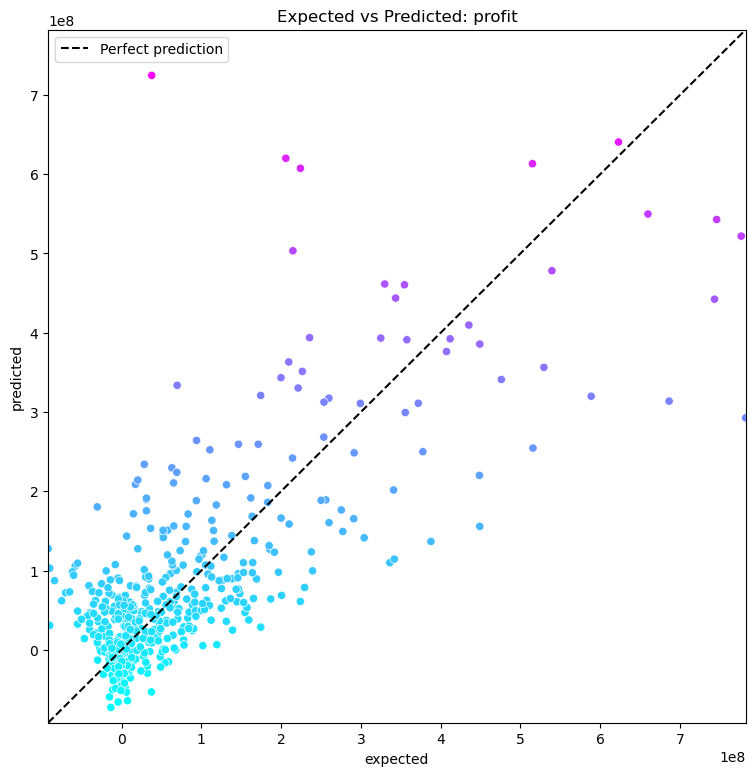

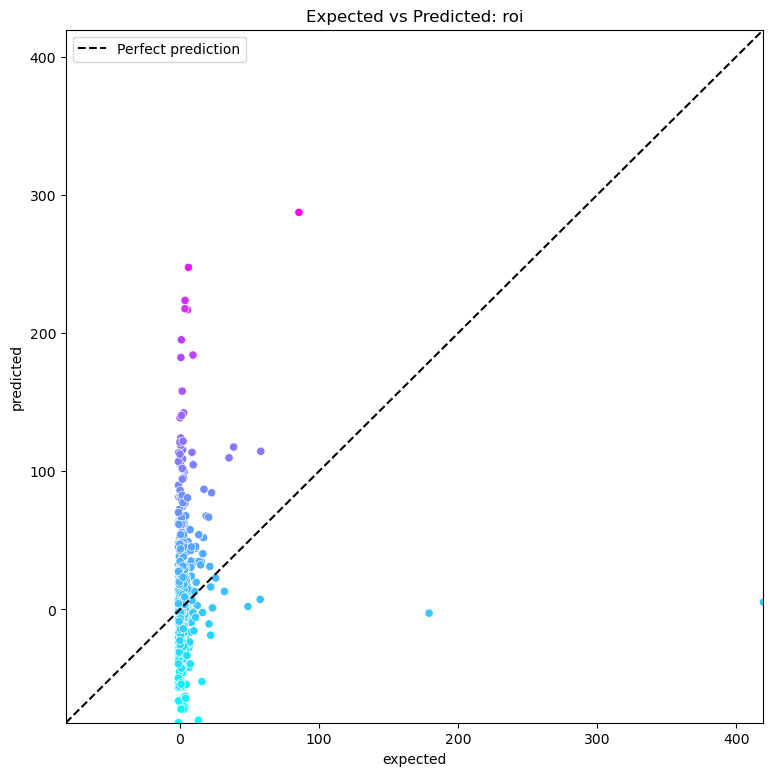

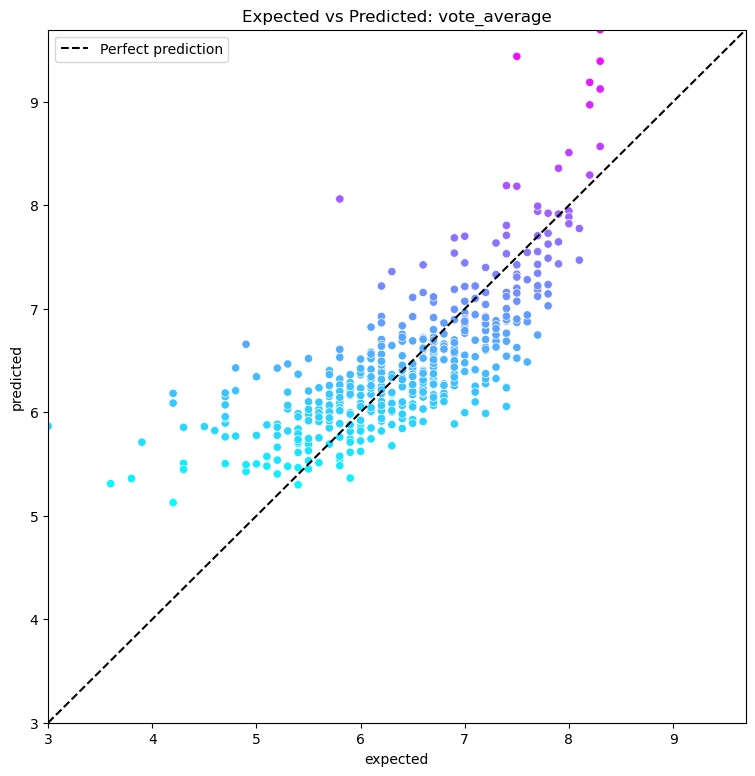

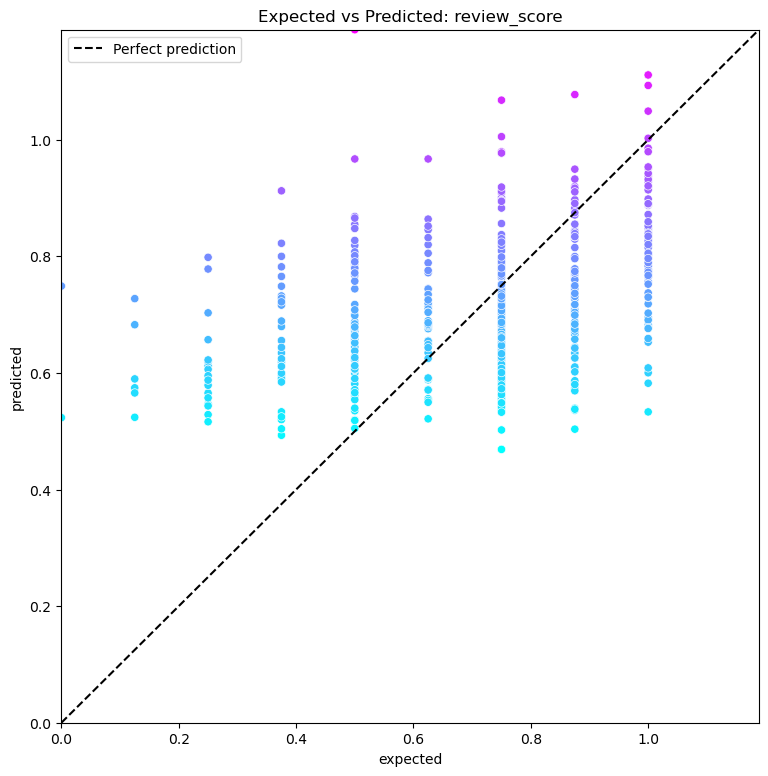

KeyError: 'revenue'

In [30]:
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.linear_model import ElasticNet, Lasso, Ridge

continuous_cols = [
    'budget',
    'popularity',
    'runtime',
    'vote_count',
    'year',
    'month',
    'day',
    'is_us_production'
]


onehot_cols = [col for col in X_train.columns if col not in continuous_cols]


preprocessor = ColumnTransformer(
    transformers=[
        ('budget', RobustScaler(), ['budget']),
        ('rest_numeric', StandardScaler(), [col for col in continuous_cols if col != 'budget']),
        ('onehot', 'passthrough', onehot_cols)
    ],
    remainder='passthrough'
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

targets = ['profit', 'roi', 'vote_average', 'review_score', 'revenue']

for target_col in targets:
    
    y_train_target = y_train[target_col]
    y_test_target  = y_test[target_col]

    
    linear_regression = LinearRegression()
    linear_regression.fit(X_train_scaled, y_train_target)
    predicted = linear_regression.predict(X_test_scaled)
    expected  = y_test_target

    
    EVSP = pd.DataFrame()
    EVSP['predicted'] = pd.Series(predicted)
    EVSP['expected']  = pd.Series(expected.values)

    plt.figure(figsize=(9,9))
    axes = sns.scatterplot(
        data=EVSP,
        x='expected',
        y='predicted',
        hue='predicted',
        palette='cool',
        legend=False
    )
    
    start = min(expected.min(), predicted.min())
    end   = max(expected.max(), predicted.max())
    axes.set_xlim(start, end)
    axes.set_ylim(start, end)
    plt.plot([start, end], [start, end], 'k--', label='Perfect prediction')
    axes.legend()
    plt.title(f"Expected vs Predicted: {target_col}")
    plt.show()
    

Based off of these results the model needs some more tuning, so we will apply regression model metrics.

In [28]:
from sklearn import metrics
from sklearn.linear_model import ElasticNet, Lasso, Ridge



for target_col in targets:

    print(f"TARGET: {target_col}")
 
    
    y_train_target = y_train[target_col]
    y_test_target  = y_test[target_col]
    
    # Train
    linear_regression = LinearRegression()
    linear_regression.fit(X_train_scaled, y_train_target)
    
    # Predict
    predicted = linear_regression.predict(X_test_scaled)
    expected  = y_test_target
    
    # Results
    EVSP = pd.DataFrame()
    EVSP['predicted'] = pd.Series(predicted)
    EVSP['expected']  = pd.Series(expected.values)
    
    # Metrics
    r2   = metrics.r2_score(expected, predicted)
    mae  = metrics.mean_absolute_error(expected, predicted)
    rmse = np.sqrt(metrics.mean_squared_error(expected, predicted))
    
    print(f"R² Score:  {r2:.4f}")
    print(f"MAE:       {mae:.2f}")
    print(f"RMSE:      {rmse:.2f}")
    print(EVSP.head(10))



TARGET: profit
R² Score:  0.5312
MAE:       61997599.32
RMSE:      93936833.26
      predicted   expected
0 -3.450900e+07   -7500000
1 -1.158288e+07  -15600000
2  6.177210e+07  130638883
3  2.669058e+07   24892047
4  1.030257e+08  -90000000
5  6.010121e+07   59940815
6  4.631886e+07  -39617593
7  6.753098e+07   52278331
8  1.650101e+07   -1800000
9  1.060080e+08  -58067057
TARGET: roi
R² Score:  -4.9856
MAE:       35.32
RMSE:      53.83
   predicted  expected
0 -51.956736 -0.441176
1  -5.758376 -1.000000
2  32.154630  4.354629
3  -9.226127  3.318940
4   1.148257 -1.000000
5  19.783712  0.999014
6  -3.140870 -0.792352
7 -24.955690  2.091133
8   2.777342 -1.000000
9   1.343895 -0.430126
TARGET: vote_average
R² Score:  0.5453
MAE:       0.44
RMSE:      0.59
   predicted  expected
0   6.393098       7.0
1   6.088485       4.2
2   6.922090       7.2
3   6.924479       6.5
4   5.364075       5.9
5   5.884190       5.8
6   6.519871       5.5
7   6.711944       6.4
8   6.926156       6.2
9   5